# Dependencies

Install Dependencies

In [1]:
# RL environment
!pip install -q gymnasium[atari]
!pip install -q ale-py

# Deep Learning
!pip install -q torch torchvision

# Experiment tracking
!pip install -q wandb

# Utilities
!pip install -q pyyaml matplotlib numpy opencv-python

Verify Installations

In [2]:
import torch
import gymnasium as gym
import numpy as np
import wandb
import ale_py

print("Torch:", torch.__version__)
print("Gymnasium:", gym.__version__)
print("NumPy:", np.__version__)
print("WandB:", wandb.__version__)
print("Ale-py:", ale_py.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cpu
Gymnasium: 1.3.0
NumPy: 2.0.2
WandB: 0.27.2
Ale-py: 0.12.0
CUDA available: False


Connect to Google Drive

In [3]:
# from google.colab import drive
# drive.mount('/content/gdrive/MyDrive/breakout_ddqn/checkpoint')


from google.colab import drive
import os

gdrive_path='/content/gdrive/MyDrive/breakout_ddqn/checkpoint'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

Mounted at /content/gdrive
['DQN_Extensions', 'template.ipynb']


Clone github repo

In [4]:
!git clone https://github.com/sarthaknandwani/DQN_Extensions.git
%cd DQN_Extensions

fatal: destination path 'DQN_Extensions' already exists and is not an empty directory.
/content/gdrive/MyDrive/breakout_ddqn/checkpoint/DQN_Extensions


Login to WandB

In [5]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nandwanisarthak (nandwanisarthak-kiel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Environment Setup

Quick breakout environment test

In [6]:
env = gym.make("ALE/Breakout-v5")

obs, info = env.reset()

print("Observation shape:", obs.shape)
print("Action space:", env.action_space)

Observation shape: (210, 160, 3)
Action space: Discrete(4)


Basic environment code

In [7]:
import gymnasium as gym

#create environment
env = gym.make("ALE/Breakout-v5")

#reset environment
obs, info = env.reset()

print("Observation shape:", obs.shape)
print("Observation dtype:", obs.dtype)

#action space
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)



Observation shape: (210, 160, 3)
Observation dtype: uint8
Action space: Discrete(4)
Number of actions: 4


In [8]:
#random actions
for step in range(10):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(
        f"Step: {step} | "
        f"Action: {action} | "
        f"Reward: {reward}"
    )

    if terminated or truncated:
        print("Episode finished, resetting environment")
        obs, info = env.reset()


# verify final observation
print("Final observation shape:", obs.shape)

# close environment
env.close()

Step: 0 | Action: 1 | Reward: 0.0
Step: 1 | Action: 1 | Reward: 0.0
Step: 2 | Action: 2 | Reward: 0.0
Step: 3 | Action: 1 | Reward: 0.0
Step: 4 | Action: 3 | Reward: 0.0
Step: 5 | Action: 0 | Reward: 0.0
Step: 6 | Action: 3 | Reward: 0.0
Step: 7 | Action: 1 | Reward: 0.0
Step: 8 | Action: 1 | Reward: 0.0
Step: 9 | Action: 3 | Reward: 0.0
Final observation shape: (210, 160, 3)


# Atari Preprocessing

Here we convert raw frames (210,160,3) RGB to DQN Input (84, 84, 4) grayscale frame stack

Dependency

In [9]:
!pip install -q opencv-python

Create base environment

In [10]:
import gymnasium as gym
import numpy as np
import cv2

env = gym.make("ALE/Breakout-v5")
obs, info = env.reset()

print(obs.shape)

(210, 160, 3)


Preprocess the frame

In [11]:
def preprocess_frame(frame):

    # Convert to grayscale
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    # Resize to 84x84
    frame = cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)

    # Normalize (optional but recommended)
    frame = frame / 255.0

    return frame

Test preprocessing function

In [12]:
processed = preprocess_frame(obs)

print("Raw:", obs.shape)
print("Processed:", processed.shape)
print("Min/Max:", processed.min(), processed.max())

Raw: (210, 160, 3)
Processed: (84, 84)
Min/Max: 0.0 0.5803921568627451


Frame stack class

In [13]:
class FrameStack:

    def __init__(self, k=4):

        self.k = k
        self.frames = []

    def reset(self, frame):

        processed = preprocess_frame(frame)

        self.frames = [processed for _ in range(self.k)]

        return np.stack(self.frames, axis=0)

    def append(self, frame):

        processed = preprocess_frame(frame)

        self.frames.pop(0)
        self.frames.append(processed)

        return np.stack(self.frames, axis=0)

Test frame stack class and functions

In [14]:
stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)

print("Stacked shape:", state.shape)

Stacked shape: (4, 84, 84)


Run environment with preprocessing

In [15]:
obs, _ = env.reset()

state = stacker.reset(obs)

for step in range(10):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state = stacker.append(next_obs)

    print(
        f"Step {step} | "
        f"Reward {reward} | "
        f"State shape {next_state.shape}"
    )

    if terminated or truncated:
        obs, _ = env.reset()
        state = stacker.reset(obs)

Step 0 | Reward 0.0 | State shape (4, 84, 84)
Step 1 | Reward 0.0 | State shape (4, 84, 84)
Step 2 | Reward 0.0 | State shape (4, 84, 84)
Step 3 | Reward 0.0 | State shape (4, 84, 84)
Step 4 | Reward 0.0 | State shape (4, 84, 84)
Step 5 | Reward 0.0 | State shape (4, 84, 84)
Step 6 | Reward 0.0 | State shape (4, 84, 84)
Step 7 | Reward 0.0 | State shape (4, 84, 84)
Step 8 | Reward 0.0 | State shape (4, 84, 84)
Step 9 | Reward 0.0 | State shape (4, 84, 84)


# Environment Validation

Display Raw Atari Frame

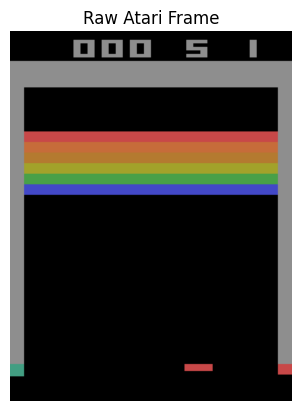

In [16]:
import matplotlib.pyplot as plt

env = gym.make("ALE/Breakout-v5")

obs, info = env.reset()

plt.imshow(obs)
plt.title("Raw Atari Frame")
plt.axis("off")
plt.show()

Display preprocessed frame

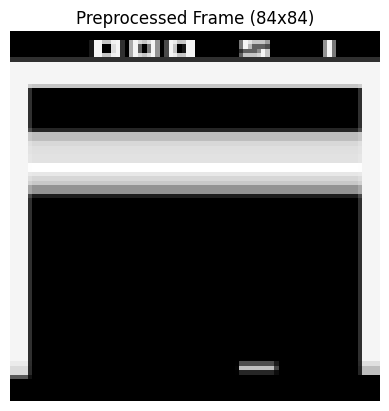

In [17]:
processed = preprocess_frame(obs)

plt.imshow(processed, cmap="gray")
plt.title("Preprocessed Frame (84x84)")
plt.axis("off")
plt.show()

Verify Shapes

In [18]:
print("Raw shape:", obs.shape)
print("Processed shape:", processed.shape)

Raw shape: (210, 160, 3)
Processed shape: (84, 84)


Visualise Frame Stack

In [19]:
stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)

print(state.shape)

(4, 84, 84)


Plot all 4 frames

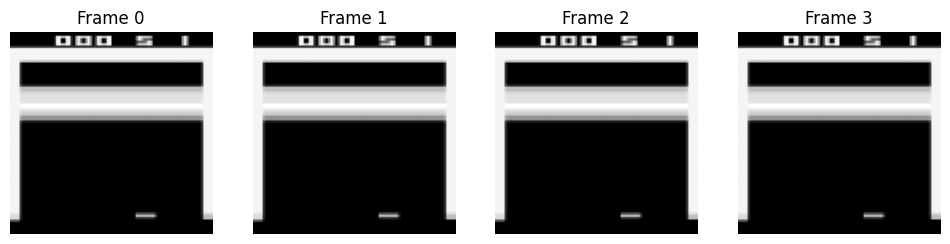

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i in range(4):
    axes[i].imshow(state[i], cmap="gray")
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")

plt.show()

Take some Random actions

In [21]:
for _ in range(10):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    state = stacker.append(obs)

    if terminated or truncated:
        obs, _ = env.reset()
        state = stacker.reset(obs)

New frames

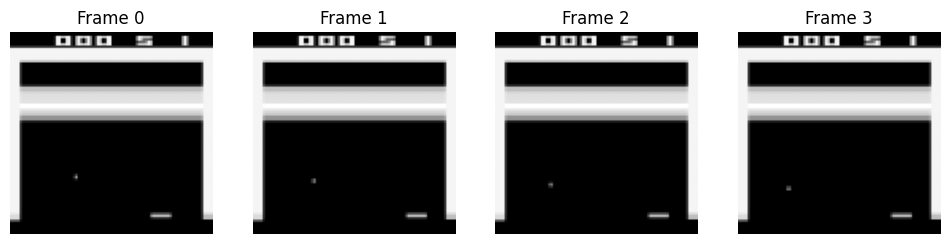

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i in range(4):
    axes[i].imshow(state[i], cmap="gray")
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")

plt.show()

Verify State Ready for CNN

In [23]:
print(state.shape)
print(state.dtype)
print(state.min())
print(state.max())

(4, 84, 84)
float64
0.0
0.5803921568627451


# Replay Buffer

ReplayBuffer Class

In [24]:
import random
import numpy as np
from collections import deque

class ReplayBuffer:

    def __init__(self, capacity):

        self.buffer = deque(maxlen=capacity)

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.stack(states),
            np.array(actions),
            np.array(rewards),
            np.stack(next_states),
            np.array(dones)
        )

    def __len__(self):

        return len(self.buffer)

Create Buffer

In [25]:
buffer = ReplayBuffer(
    capacity=100000
)

Add dummy data

In [26]:
state = np.zeros((4,84,84))

next_state = np.ones((4,84,84))

buffer.add(
    state,
    2,
    1.0,
    next_state,
    False
)

print(len(buffer))

for i in range(100):

    buffer.add(
        np.random.rand(4,84,84),
        np.random.randint(4),
        np.random.rand(),
        np.random.rand(4,84,84),
        False
    )

print(len(buffer))

1
101


Sample batch and check shape

In [27]:
states, actions, rewards, next_states, dones = buffer.sample(batch_size=32)

print(states.shape)
print(actions.shape)
print(rewards.shape)
print(next_states.shape)
print(dones.shape)

(32, 4, 84, 84)
(32,)
(32,)
(32, 4, 84, 84)
(32,)


Testing with real breakout data

In [28]:
buffer = ReplayBuffer(1000)

env = gym.make("ALE/Breakout-v5")

stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)


for _ in range(100):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state = stacker.append(next_obs)

    done = terminated or truncated

    buffer.add(
        state,
        action,
        reward,
        next_state,
        done
    )

    state = next_state

    if done:
        obs, _ = env.reset()
        state = stacker.reset(obs)

Sample batch

In [29]:
states, actions, rewards, next_states, dones = buffer.sample(32)

print(states.shape)

(32, 4, 84, 84)


# CNN Q-Network

Create Q-Network Class

In [30]:
import torch
import torch.nn as nn

class QNetwork(nn.Module):

    def __init__(self, num_actions):

        super().__init__()

        # feature extractor
        self.features = nn.Sequential(
            # to reduce 4 X 84 X 84 to 32 X 20 X 20
            nn.Conv2d(
                in_channels=4,
                out_channels=32,
                kernel_size=8,
                stride=4
            ),

            nn.ReLU(),

            # to look at medium scale patterns
            # 32 X 20 X 20 to 64 X 9 X 9
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=4,
                stride=2
            ),

            nn.ReLU(),

            # to capture finer details
            # 64 X 9 X 9 to 64 X 7 X 7
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1
            ),

            nn.ReLU()
        )

        # decision maker
        self.fc = nn.Sequential(

            # 64 X 7 X 7 = 3136 to 512
            nn.Linear(
                3136,
                512
            ),

            nn.ReLU(),

            # 512 to 4
            nn.Linear(
                512,
                num_actions
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.fc(x)

        return x

Create a dummy instance of the Network

In [31]:
num_actions = 4

q_network = QNetwork(
    num_actions
)

state = np.random.rand(4, 84, 84).astype(np.float32)

state = torch.tensor(state).unsqueeze(0)

print(state.shape)
# first dimension = batch_size

# forward function call with state
q_values = q_network(state)

print(q_values)
print(q_values.shape)
print(torch.argmax(q_values))

torch.Size([1, 4, 84, 84])
tensor([[-0.0158,  0.0360,  0.0410,  0.0272]], grad_fn=<AddmmBackward0>)
torch.Size([1, 4])
tensor(2)


Test Batch input

In [32]:
batch = torch.rand(32, 4, 84, 84)

# forward function call with batch
q_values = q_network(batch)

print(q_values.shape)

torch.Size([32, 4])


Number of Parameters for Atari

In [33]:
total_params = sum(
    p.numel()
    for p in q_network.parameters()
)

print(total_params)

1686180


# ε - Greedy Action Selection

Action Selection Function

In [34]:
import random
import torch

def select_action(state, q_network, epsilon, action_space):

    if random.random() < epsilon:

        return action_space.sample()

    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():

        q_values = q_network(state)

    return q_values.argmax(dim=1).item()

Test Function

In [35]:
num_actions = env.action_space.n

q_network = QNetwork(
    num_actions
)

obs, _ = env.reset()

state = stacker.reset(obs)

action = select_action(
    state,
    q_network,
    epsilon=0.1,
    action_space=env.action_space
)

print(action)

3


Run a short episode

In [36]:
obs, _ = env.reset()

state = stacker.reset(obs)

for step in range(20):

    action = select_action(
        state,
        q_network,
        epsilon=0.2,
        action_space=env.action_space
    )

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state = stacker.append(next_obs)

    state = next_state

    if terminated or truncated:
        break

    print(
        f"Step {step}: Action {action}"
    )

Step 0: Action 3
Step 1: Action 3
Step 2: Action 3
Step 3: Action 3
Step 4: Action 3
Step 5: Action 2
Step 6: Action 0
Step 7: Action 1
Step 8: Action 3
Step 9: Action 3
Step 10: Action 3
Step 11: Action 3
Step 12: Action 3
Step 13: Action 3
Step 14: Action 1
Step 15: Action 3
Step 16: Action 3
Step 17: Action 3
Step 18: Action 3
Step 19: Action 3


# DQN Training Step (Loss and Update)

Create Optimizer

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(
    q_network.parameters(),
    lr=1e-4
)

In [59]:
# hyperparameters
gamma = 0.99

# sample batch from replay buffer
states, actions, rewards, next_states, dones = buffer.sample(32)

# convert to tensors
states = torch.tensor(states, dtype=torch.float32)
actions = torch.tensor(actions, dtype=torch.int64)
rewards = torch.tensor(rewards, dtype=torch.float32)
next_states = torch.tensor(next_states, dtype=torch.float32)
dones = torch.tensor(dones, dtype=torch.float32)

In [60]:
# current Q-values
q_values = q_network(states)


# select only taken actions
q_values = q_values.gather(
    1,
    actions.unsqueeze(1)
).squeeze(1)

In [61]:
# compute next Q-values
with torch.no_grad():

    next_q_values = q_network(next_states)

    max_next_q = next_q_values.max(dim=1)[0]

# apply bellman target
target_q = rewards + gamma * (1 - dones) * max_next_q

In [62]:
# compute loss
loss_fn = nn.MSELoss()

loss = loss_fn(q_values, target_q)

# backpropogation
optimizer.zero_grad()

loss.backward()

optimizer.step()

print(loss.item())

0.002382672391831875


# DQN Target Network

Currently, both prediction and target are computed by the Q network which can cause explosion of Q-values, unstable loss and divergence of training. We need a separate target network.

In [70]:
# same code as before


optimizer = optim.Adam(
    q_network.parameters(),
    lr=1e-4
)

# hyperparameters
gamma = 0.99

# sample batch from replay buffer
states, actions, rewards, next_states, dones = buffer.sample(32)

# convert to tensors
states = torch.tensor(states, dtype=torch.float32)
actions = torch.tensor(actions, dtype=torch.int64)
rewards = torch.tensor(rewards, dtype=torch.float32)
next_states = torch.tensor(next_states, dtype=torch.float32)
dones = torch.tensor(dones, dtype=torch.float32)

# current Q-values
q_values = q_network(states)


# select only taken actions
q_values = q_values.gather(
    1,
    actions.unsqueeze(1)
).squeeze(1)

Create Target Network

In [71]:
# main network
q_network = QNetwork(num_actions)

# target network
target_network = QNetwork(num_actions)

Copy weights

In [72]:
target_network.load_state_dict(
    q_network.state_dict()
)

<All keys matched successfully>

Set evaluation mode

In [73]:
target_network.eval()

QNetwork(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
)

Use target network for targets

In [74]:
with torch.no_grad():

    next_q = target_network(next_states)

    max_next_q = next_q.max(dim=1)[0]

target_q = rewards + gamma * (1 - dones) * max_next_q

In [77]:
# compute loss
loss_fn = nn.MSELoss()

loss = loss_fn(q_values, target_q)

# backpropogation
optimizer.zero_grad()

#loss.backward()

optimizer.step()

print(loss.item())

0.0019627234432846308


# Training Step

In [79]:
# create optimizer

optimizer = torch.optim.Adam(
    q_network.parameters(),
    lr=1e-4
)

# loss function
loss_fn = torch.nn.MSELoss()


Training function

In [80]:
def train_step(replay_buffer, q_network, target_network, optimizer, batch_size, gamma):
  # sample batch
  states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

  # convert to tensors
  states = torch.tensor(states, dtype=torch.float32)
  actions = torch.tensor(actions, dtype=torch.int64)
  rewards = torch.tensor(rewards, dtype=torch.float32)
  next_states = torch.tensor(next_states, dtype=torch.float32)
  dones = torch.tensor(dones, dtype=torch.float32)

  # forward pass
  q_values = q_network(states)

  # gather the actions taken
  q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

  # compute target
  with torch.no_grad():

    next_q_values = target_network(next_states)

    max_next_q = next_q_values.max(dim=1)[0]

  # bellman target
  target_q = rewards + gamma * (1 - dones) * max_next_q

  # compute loss
  loss = loss_fn(q_values, target_q)

  # backpropogation
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # return loss
  return loss.item()

Fill the buffer with some random transitions

In [86]:
obs, _ = env.reset()

state = stacker.reset(obs)

for _ in range(1000):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, _ = env.step(action)

    next_state = stacker.append(next_obs)

    done = terminated or truncated

    buffer.add(
        state,
        action,
        reward,
        next_state,
        done
    )

    state = next_state

    if done:

        obs, _ = env.reset()

        state = stacker.reset(obs)

# check size of buffer
print(len(buffer))

# check if sample works
states, actions, rewards, next_states, dones = buffer.sample(32)

print(states.shape)
print(actions.shape)

1000
(32, 4, 84, 84)
(32,)


Test the training step

In [94]:
loss = train_step(replay_buffer=buffer, q_network=q_network, target_network=target_network,
                  optimizer=optimizer, batch_size=32, gamma=0.99)

print(loss)

0.05923273786902428
